# Import Packages

In [144]:
import os
import re
from glob import glob
import random
import warnings
import matplotlib.pyplot as plt
from cmcrameri import cm
import seaborn as sns
from pandas import DataFrame
import numpy as np
from IPython.display import display
from datetime import datetime
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import pydeck as pdk
import contextily as ctx
import geopandas as gpd
from numpy import abs, nanpercentile
from pathlib import Path
from scipy.stats import norm

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style('whitegrid')
%matplotlib inline
cmap = cm.managua

fs = 12

# Settings

In [60]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

dir_results = '../output/gev_analysis/2026-03-12/'
dir_data_pkl = '../output/gev_analysis/2026-03-12/data.parquet'

In [61]:
HINDCAST_START = 1960
HINDCAST_END = 2026

In [62]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [63]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [65]:
CONFIDENCE_INTERVAL = 0.9 # two-side 90% CI interval (5% each side)

In [8]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0 #random.choice(arange(0, 9579))
end_location = 100 #start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 0–100


# Import Data

### Import Raw Data from Models

In [ ]:
ls_files = [file for file in glob(path_data + '*.nc')]
ls_files

In [ ]:
dic_data_per_model = dbf.import_all_models(ls_files)

### Import regression results for location trend regression

In [35]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(dir_results)

loading ../output/gev_analysis/2026-03-12//stationary_per_year.pkl
loading ../output/gev_analysis/2026-03-12//nonstationary.pkl
loading ../output/gev_analysis/2026-03-12//LatLon.pkl
loading ../output/gev_analysis/2026-03-12//location_info.pkl


# Data Processing...

### BiasCorrection,...

In [ ]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [ ]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

# VISUALS

### Plot Map of Missing Data

In [36]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

NameError: name 'dic_data_per_location' is not defined

In [37]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, 
    dir_export=None
    )

NameError: name 'dic_data_per_model' is not defined

In [ ]:
display(fig_map)

### Regression Plot $μ$ - non-stationary vs annual stationary

KeyboardInterrupt: 

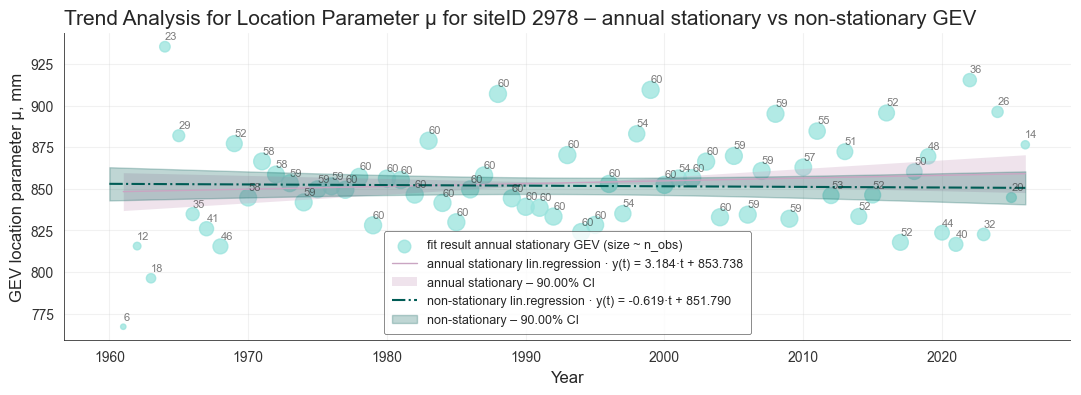

In [42]:
dic_fig_regression = {}
ls_missing = []
for loc_id in results_annual_stat_all.keys():
    if loc_id > 2906:
        if results_nonstat_all[loc_id] is None:
            ls_missing.append(loc_id)
            print(f'Skipping side {loc_id}, no nonstationary results (counting {len(ls_missing)})')
            dic_fig_regression[loc_id] = None
            continue
        
        years_, dic_trend = gev.prepare_for_regression(
            annual_stationary=results_annual_stat_all[loc_id], 
            nonstationary=results_nonstat_all[loc_id],
            years_mean=results_nonstat_all[loc_id]['years_mean'], 
            years_std=results_nonstat_all[loc_id]['years_std'], 
            hindcast_start=HINDCAST_START, hindcast_end=HINDCAST_END,
            confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000
            ) 

        fig_reg = dbplt.plot_location_regression(
            loc_id, years_, dic_trend, results_annual_stat_all[loc_id], fontsize=12,
            confidence_level_pc=CONFIDENCE_INTERVAL, 
            axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], 
            )
        
        dic_fig_regression[loc_id] = fig_reg

In [10]:
for loc_id in dic_fig_regression.keys():
    if dic_fig_regression[loc_id]:
        ut.store_location_regression(
            dic_fig_regression[loc_id],loc_id, 
            location_geo_info[loc_id], location_point_info[loc_id], 
            Path('../output/gev_analysis/2026-03-05/')
            )

### Plot Map of Trends of Non-Stationary and Annual Stationary Approach

two-sided 90% CI -> z = 1.645

#### interactive PyDeck

In [151]:
def extract_mu_for_all_sites_ns(results):
    dic_mu = dict()
    for loc_id in results.keys():
        try:
            mu0, mu1, _, _ = results[loc_id]['params_hat']
            mu0_std, mu1_std, _, _ = results[loc_id]['params_std']
            dic_mu[loc_id] = (mu0, mu0_std, mu1, mu1_std)
        except:
            dic_mu[loc_id] = (None, None, None, None)
        
    return DataFrame(dic_mu, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000


def extract_mu_for_all_sites_astat(results):
    dic_mu = dict()
    for loc_id in results.keys():
        try:
            mu0, mu1 = results[loc_id]['mu_trend']['mu0'], results[loc_id]['mu_trend']['mu1']
            mu0_std, mu1_std = results[loc_id]['mu_trend']['mu0_se'], results[loc_id]['mu_trend']['mu1_se']
            dic_mu[loc_id] = (mu0, mu0_std, mu1, mu1_std)
        except:
            dic_mu[loc_id] = (None, None, None, None)
        
    return DataFrame(dic_mu, index=['mu0_mm', 'mu0_std_mm', 'mu1_mm/yr', 'mu1_std_mm/yr']).T*1000


def get_confidence_intervals_mu1(df_mu, confidence_level_pc):
    z_ci = norm.ppf(1 - (1-confidence_level_pc)/2) 
    return DataFrame([
        df_mu['mu1_mm/yr'] - z_ci * df_mu['mu1_std_mm/yr'],
        df_mu['mu1_mm/yr'] + z_ci * df_mu['mu1_std_mm/yr']], index=['mu1_upper', 'mu1_lower']
    ).T
    

def prep_for_plot(result, confidence_level_pc, approach):
    if approach == 'non-stationary':
        df_mu = extract_mu_for_all_sites_ns(result)
    elif approach == 'annual-stationary':
        df_mu = extract_mu_for_all_sites_astat(result)
    ci_mu1 = get_confidence_intervals_mu1(df_mu=df_mu, confidence_level_pc=confidence_level_pc)
    
    rows = []
    for loc_id in df_mu.index:

        lat, lon = location_geo_info[loc_id]

        mu1 = df_mu.loc[loc_id, 'mu1_mm/yr']
        se_mu1 = df_mu.loc[loc_id, 'mu1_std_mm/yr']

        ci_mu1_lower = ci_mu1.loc[loc_id]['mu1_lower']
        ci_mu1_upper = ci_mu1.loc[loc_id]['mu1_upper']
        
        if ci_mu1_lower > ci_mu1_upper:
            a, b = ci_mu1_lower, ci_mu1_upper
            ci_mu1_upper = a
            ci_mu1_lower = b
        significant = not (ci_mu1_lower <= 0 <= ci_mu1_upper)

        rows.append({
            "loc_id": loc_id,
            "lat": lat,
            "lon": lon,
            "mu1": mu1,
            "mu1_std": se_mu1,
            "mu1_ci_lower": ci_mu1_lower,
            "mu1_ci_upper": ci_mu1_upper,
            "significant": significant
        })

    return DataFrame(rows), df_mu


def convert_mu1_to_color(df_plot):    
    df = df_plot.copy()
        
    max_abs = nanpercentile(abs(df["mu1"]), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    def mu1_to_color(val):
        rgba = cmap(norm(val))
        return [int(255*c) for c in rgba[:3]]

    df["color"] = df["mu1"].apply(mu1_to_color)
    return df


def convert_mu1_to_alpha(df_plot):
    """
    Converting uncertainty into transparency: higher uncertainty → more transparent
    """
    max_se = nanpercentile(abs(df_plot["mu1_std"]), 98)
    def se_to_alpha(se):
        norm_se = min(se / max_se, 1)
        if np.isnan(norm_se):
            alpha = int(10)
        else:
            alpha = int(255 * (1 - norm_se))      
        return max(alpha, 10)  # prevent fully invisible

    df_plot["alpha"] = df_plot["mu1_std"].apply(se_to_alpha)
    return df_plot


def custom_color_for_mu1(df_plot):

    df_plot = convert_mu1_to_color(df_plot)
    df_plot = convert_mu1_to_alpha(df_plot)

    df_plot["color_rgba"] = df_plot.apply(lambda row: row["color"] + [row["alpha"]],axis=1)
    return df_plot


def create_color_legend(cmap, max_abs):

    values = np.linspace(-max_abs, max_abs, 5)

    legend_rows = ""
    for v in values:
        rgba = cmap((v + max_abs) / (2 * max_abs))
        r, g, b = [int(255*c) for c in rgba[:3]]

        legend_rows += f"""
        <div style="display:flex;align-items:center">
            <div style="width:18px;height:12px;background:rgb({r},{g},{b});margin-right:6px"></div>
            {v:.2f} mm/yr
        </div>
        """

    legend_html = f"""
    <div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 180px;
    background-color: white;
    border-radius: 6px;
    box-shadow: 0px 0px 6px rgba(0,0,0,0.3);
    padding: 10px;
    font-size: 13px;
    z-index: 9999;
    ">
    <b>Trend μ₁ (mm/yr)</b><br>
    {legend_rows}

    <br>
    <b>Transparency</b><br>
    More transparent → higher uncertainty
    </div>
    """

    return legend_html


def create_gradient_legend(cmap, norm, width=180, height=15, n_steps=100):
    """
    Create an HTML gradient legend matching your colormap and normalization.

    cmap: matplotlib colormap
    norm: matplotlib TwoSlopeNorm or Normalize
    width: width of the legend in px
    height: height of the gradient bar in px
    n_steps: number of gradient steps
    """
    # generate colors
    gradient = []
    for i in range(n_steps):
        val = norm.vmin + i / (n_steps-1) * (norm.vmax - norm.vmin)
        rgba = cmap(norm(val))
        r, g, b = [int(255*c) for c in rgba[:3]]
        gradient.append(f"rgb({r},{g},{b})")

    gradient_str = ",".join(gradient)

    # HTML for gradient legend
    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 40px;
        left: 40px;
        width: {width}px;
        font-size: 12px;
        background-color: white;
        border-radius: 6px;
        box-shadow: 0px 0px 6px rgba(0,0,0,0.3);
        padding: 6px;
        z-index: 9999;
    ">
        <b>Trend μ₁ (mm/yr)</b><br>
        <div style="
            height: {height}px;
            background: linear-gradient(to right, {gradient_str});
            border: 1px solid black;
            margin: 4px 0;
        "></div>
        <div style="display:flex;justify-content:space-between;">
            <span>{norm.vmin:.2f}</span>
            <span>0</span>
            <span>{norm.vmax:.2f}</span>
        </div>
        <br>
        <b>Transparency</b><br>
        More transparent → higher uncertainty
    </div>
    """
    return legend_html


def plot_mu1_for_sites(
    df_plot, approach, inital_zoom, radius=10000, file_name="Map_trend_location_including_ci", saving_map:bool=True
    ):
    df_plot["mu1_str"] = df_plot["mu1"].map("{:.3f}".format)
    df_plot["mu1_std_str"] = df_plot["mu1_std"].map("{:.3f}".format)
    df_plot["mu1_ci_lower_str"] = df_plot["mu1_ci_lower"].map("{:.3f}".format)
    df_plot["mu1_ci_upper_str"] = df_plot["mu1_ci_upper"].map("{:.3f}".format)
    df_plot["lat_str"] = df_plot["lat"].map("{:.3f}".format)
    df_plot["lon_str"] = df_plot["lon"].map("{:.3f}".format)

    layer = pdk.Layer(
        "ScatterplotLayer",
        data=df_plot,
        get_position='[lon, lat]',
        get_fill_color="color_rgba",
        get_radius=radius,  # fixed if using alpha
        pickable=True,
    )

    view_state = pdk.ViewState(
        latitude=df_plot["lat"].mean(),
        longitude=df_plot["lon"].mean(),
        zoom=inital_zoom,
    )
    
    max_abs = np.nanpercentile(abs(df_plot["mu1"]), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    #legend_html = create_color_legend(cmap, max_abs)
    legend_html = create_gradient_legend(cmap, norm, width=250, height=15, n_steps=100)

    deck = pdk.Deck(
        layers=[layer],
        initial_view_state=view_state,
        map_style="https://tiles.openfreemap.org/styles/positron",
        tooltip={
            "html": """
                <b>Location</b><br>
                Lat: {lat_str}<br>
                Lon: {lon_str}<br>
                μ₁: {mu1_str} mm/yr<br>
                std_error: {mu1_std_str} mm/yr<br>
            """,
            "style": {"backgroundColor": "lightgray", "color": axes_color, "padding": "8px"}
        }
        #  ci_lower: {mu1_ci_lower_str} mm/yr<br> ci_upper: {mu1_ci_upper_str} mm/yr<br>
        )

    if saving_map:
        today_ = str(datetime.today().date().isoformat()) 

        output_path = f"../output/gev_analysis/{today_}/figures/"
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        if approach not in file_name:
            file_name = file_name.split('.')[0] + '_' + '_'.join(approach.split(' ')) + '.html'
        print('map stored as %s', output_path + file_name)
        full_path = output_path + file_name
        deck.to_html(full_path)

        with open(full_path, "r", encoding="utf-8") as f:
            html = f.read()

        html = re.sub(r"<title>.*?</title>", f"<title>GEV μ1 trend map ({approach})</title>", html, flags=re.IGNORECASE)
        html = html.replace("</body>", legend_html + "\n</body>")

        with open(full_path, "w", encoding="utf-8") as f:
            f.write(html)
    return deck


##### Non-Stationary Approach

In [152]:
df_plot_ns, df_mu_ns = prep_for_plot(results_nonstat_all, CONFIDENCE_INTERVAL, approach='non-stationary')
print(f'non-stationary data: {df_plot_ns.shape} out of {df_mu_ns.shape}')

df_plot_ns = custom_color_for_mu1(df_plot_ns)

non-stationary data: (9589, 8) out of (9589, 4)


In [153]:
map_ns = plot_mu1_for_sites(
    df_plot=df_plot_ns, inital_zoom=3.5, radius=9000, saving_map=True,
    approach='non-stationary approach', file_name="Map_trend_location_including_ci", 
    )

map stored as %s ../output/gev_analysis/2026-03-13/figures/Map_trend_location_including_ci_non-stationary_approach.html


##### Annual-Stationary Approach

In [154]:
df_plot_astat, df_mu_astat = prep_for_plot(results_annual_stat_all, CONFIDENCE_INTERVAL, approach='annual-stationary')
print(f'annual stationary data: {df_plot_astat.shape} our of {df_mu_astat.shape}')

df_plot_astat = custom_color_for_mu1(df_plot_astat)

annual stationary data: (9589, 8) our of (9589, 4)


In [155]:
map_astat = plot_mu1_for_sites(
    df_plot=df_plot_astat, inital_zoom=3.5, radius=9000, saving_map=True, 
    approach='annual-stationary approach', file_name="Map_trend_location_including_ci", 
    )

map stored as %s ../output/gev_analysis/2026-03-13/figures/Map_trend_location_including_ci_annual-stationary_approach.html


#### static Matplotlib

In [139]:
def convert_ci_to_alpha(df_plot):
    max_se = nanpercentile(df_plot["mu1_std"], 98)
    df_plot['alpha'] = (1 - (df_plot['mu1_std']/max_se)).clip(0.2, 1.0)  # min alpha 0.2
    return df_plot


def remove_nan_sites(df_plot):
    ls_nan_loc = []
    for en, a in enumerate(df_plot.alpha):
        if np.isnan(a):
            ls_nan_loc.append(en)
    print(f'{len(ls_nan_loc)} missing location information')

    return df_plot.dropna()


def initialize_projection(df_clean):
    gdf = gpd.GeoDataFrame(
        df_clean, geometry=gpd.points_from_xy(df_clean['lon'], df_clean['lat']),
        crs="EPSG:4326"  # WGS84
    )

    gdf_web = gdf.to_crs(epsg=3857) 

    max_abs = nanpercentile(abs(gdf['mu1']), 98)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    max_se = nanpercentile(gdf['mu1_std'], 98)
    gdf_web['alpha'] = (1 - (gdf_web['mu1_std']/max_se)).clip(0.2, 1.0)
    gdf_web['size'] = 20 + (1 - (gdf_web['mu1_std']/max_se)).clip(0,1) * 180
    
    return gdf_web, norm


def plot_mu1_for_all_sites_v2(
    df_clean, approach, 
    ms=80, edgecolor_marker=None, lw_marker=0.1, figsize=(8,5), display_results:bool=True, save_plot:bool=False, 
    save_path:str|None=None
    ):
    
    gdf_web, norm = initialize_projection(df_clean)
    
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(
        gdf_web.geometry.x, gdf_web.geometry.y,
        c=gdf_web['mu1'], cmap=cmap, norm=norm, s=ms,
        alpha=gdf_web['alpha'], edgecolor=edgecolor_marker, linewidth=lw_marker
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

    ax.set_axis_off()  
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Location trend $μ_1$, mm/year")

    plt.title(f"Trend Map $μ_1$ · {approach}", loc='left')

    plt.tight_layout()
    if save_plot:
        if save_path is None:
            raise ValueError('Missing path for output; provide `save_path`...')
        
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True) 
    
        file_name = save_dir / f"Map_trend_location_including_ci_{approach}_approach.png"
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    plt.show() if display_results else plt.close(fig)
    return fig

##### Non-Stationary Approach

In [140]:
df_plot_ns = convert_ci_to_alpha(df_plot_ns)
df_clean_ns = remove_nan_sites(df_plot_ns)

0 missing location information


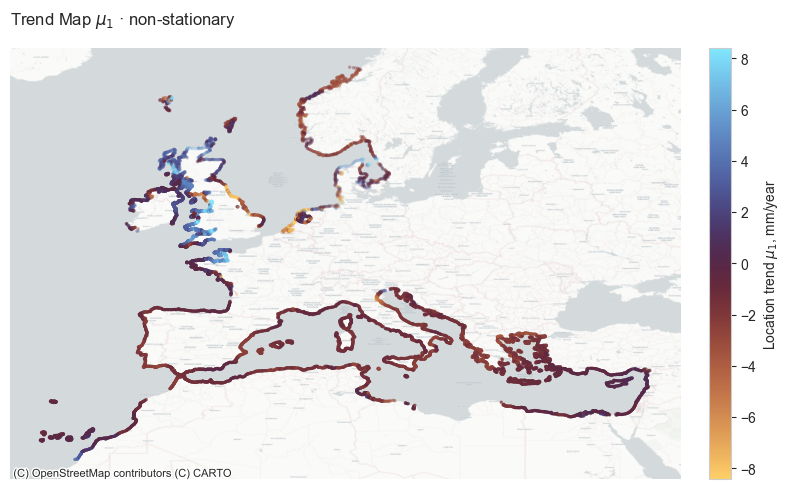

In [141]:
fig_ns = plot_mu1_for_all_sites_v2(
    df_clean_ns, approach='non-stationary', ms=5, 
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-12/figures/'
    )

##### Annual-Stationary Approach

In [142]:
df_plot_astat = convert_ci_to_alpha(df_plot_astat)
df_clean_astat = remove_nan_sites(df_plot_astat)

0 missing location information


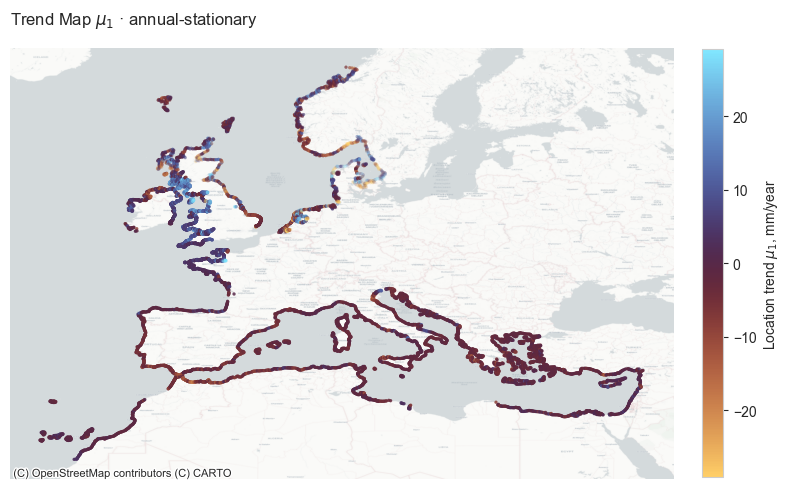

In [143]:
fig_astat = plot_mu1_for_all_sites_v2(
    df_clean_astat, approach='annual-stationary', ms=5, 
    display_results=True, save_plot=True, save_path='../output/gev_analysis/2026-03-12/figures/'
    )